# Seasonal AR Structure — GEMS TCO Spatial Mean Ozone
**Data**: 2022–2025, April–September, lat [-3,2], lon [121,131]  
**Three scales**: Hourly (8 slots/day) · Daily · Monthly  

**Key data structure:**
- 8 consecutive slots per day (~08:00–15:00), then **16–17h gap** to next day
- `Wk` = Y[d, h−k] : within-day k-slot lag (same day)
- `Dk` = Y[d−k, h] : same slot k days ago (24k-hour gap)
- Cross-boundary lag (~17h) intentionally excluded

**PACF method for within-day:**  
Naive flattening contaminates lag-7/8 with 17h cross-day gaps.  
→ Compute pooled within-day ρ(k) separately, then Levinson-Durbin recursion.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from statsmodels.tsa.stattools import pacf as _pacf, acf as _acf
from pathlib import Path

sys.path.append('/Users/joonwonlee/Documents/GEMS_TCO-1/src')
from GEMS_TCO import configuration as config
from GEMS_TCO.data_loader import load_data_dynamic_processed

DATA_CSV  = Path('/Users/joonwonlee/Documents/GEMS_TCO-1/outputs/day/seasonal_ar/spatial_means.csv')
SLOTS     = 8
CONF_MULT = 1.96

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

In [2]:
# ── Load & rebuild matrices ───────────────────────────────────────────────────
df = pd.read_csv(DATA_CSV)

day_order = (df.groupby(['year','month','day_idx'])['hours_elapsed']
               .min().reset_index().sort_values('hours_elapsed'))
rows = []
for _, row in day_order.iterrows():
    yr, mo, d = int(row['year']), int(row['month']), int(row['day_idx'])
    sub = df[(df['year']==yr) & (df['month']==mo) & (df['day_idx']==d)]
    vec = np.full(SLOTS, np.nan)
    for _, r in sub.iterrows():
        vec[int(r['slot'])] = r['spatial_mean_c']
    rows.append(vec)

Y        = np.array(rows)               # (n_days, 8)
n_days   = Y.shape[0]
daily_z  = np.nanmean(Y, axis=1)        # (n_days,)
monthly_z = (df.groupby(['year','month'])['spatial_mean_c']
               .mean().sort_index().values)

print(f'Y shape       : {Y.shape}  ({np.isfinite(Y).sum()} valid hourly obs)')
print(f'Daily series  : {len(daily_z)} days')
print(f'Monthly series: {len(monthly_z)} months')

Y shape       : (726, 8)  (5808 valid hourly obs)
Daily series  : 726 days
Monthly series: 24 months


In [3]:
# ── Helper: Levinson-Durbin PACF from pooled ρ(1..K) ─────────────────────────
def levinson_durbin(rho):
    """Return PACF[0..K] given marginal autocorrelations rho[0..K-1] = ρ(1..K)."""
    K   = len(rho)
    phi = np.zeros((K+1, K+1))
    pv  = np.zeros(K+1);  pv[0] = 1.0
    phi[1,1] = rho[0];    pv[1] = rho[0]
    for k in range(2, K+1):
        num = rho[k-1] - sum(phi[k-1,j] * rho[k-1-j] for j in range(1, k))
        den = 1.0       - sum(phi[k-1,j] * rho[j-1]   for j in range(1, k))
        if abs(den) < 1e-12: break
        phi[k,k] = num / den;  pv[k] = phi[k,k]
        for j in range(1, k):
            phi[k,j] = phi[k-1,j] - phi[k,k] * phi[k-1,k-j]
    return pv   # index 0..K

def safe_pacf(x, max_lag):
    v = x[np.isfinite(x)]
    if len(v) < max_lag + 5: return None, len(v)
    nlags = min(max_lag, len(v)//3 - 1)
    try:    return _pacf(v, nlags=nlags, method='ywm'), len(v)
    except: return None, len(v)

def safe_acf(x, max_lag):
    v = x[np.isfinite(x)]
    if len(v) < max_lag + 5: return None
    try:    return _acf(v, nlags=min(max_lag, len(v)-2), fft=True)
    except: return None

print('Helpers defined.')

Helpers defined.


## 1. Hourly — Within-day PACF (W1–W7)

In [4]:
# Pooled within-day autocorrelations ρ(k), k=1..7
rho_w, n_pairs_w = [], []
for k in range(1, SLOTS):
    xs, ys = [], []
    for d in range(n_days):
        for h in range(k, SLOTS):
            if np.isfinite(Y[d,h]) and np.isfinite(Y[d,h-k]):
                xs.append(Y[d,h-k]);  ys.append(Y[d,h])
    rho_w.append(np.corrcoef(xs, ys)[0,1])
    n_pairs_w.append(len(xs))

rho_w   = np.array(rho_w)
pacf_w  = levinson_durbin(rho_w)   # [0..7]
n_eff_w = int(np.mean(n_pairs_w))
conf_w  = CONF_MULT / np.sqrt(n_eff_w)

# Per-lag n (lag 7 has fewer pairs)
conf_per_lag = [CONF_MULT / np.sqrt(n) for n in n_pairs_w]

# Print
print(f'conf (avg n={n_eff_w}): ±{conf_w:.4f}')
print(f'{"Lag":<5} {"n_pairs":<9} {"conf":<8} {"rho":<10} {"PACF":<10} {"rho sig":<10} {"PACF sig"}')
print('-'*65)
for k in range(1, SLOTS):
    c = conf_per_lag[k-1]
    sr = '**' if abs(rho_w[k-1]) > c else 'ns'
    sp = '**' if abs(pacf_w[k])  > c else 'ns'
    print(f'W{k:<4} {n_pairs_w[k-1]:<9} ±{c:.4f}  {rho_w[k-1]:+.4f}    {pacf_w[k]:+.4f}    {sr:<10} {sp}')

conf (avg n=2904): ±0.0364
Lag   n_pairs   conf     rho        PACF       rho sig    PACF sig
-----------------------------------------------------------------
W1    5082      ±0.0275  +0.8515    +0.8515    **         **
W2    4356      ±0.0297  +0.7291    +0.0145    **         ns
W3    3630      ±0.0325  +0.6554    +0.1135    **         **
W4    2904      ±0.0364  +0.7030    +0.4284    **         **
W5    2178      ±0.0420  +0.8246    +0.5162    **         **
W6    1452      ±0.0514  +0.8221    -0.0769    **         **
W7    726       ±0.0727  +0.8361    +0.4709    **         **


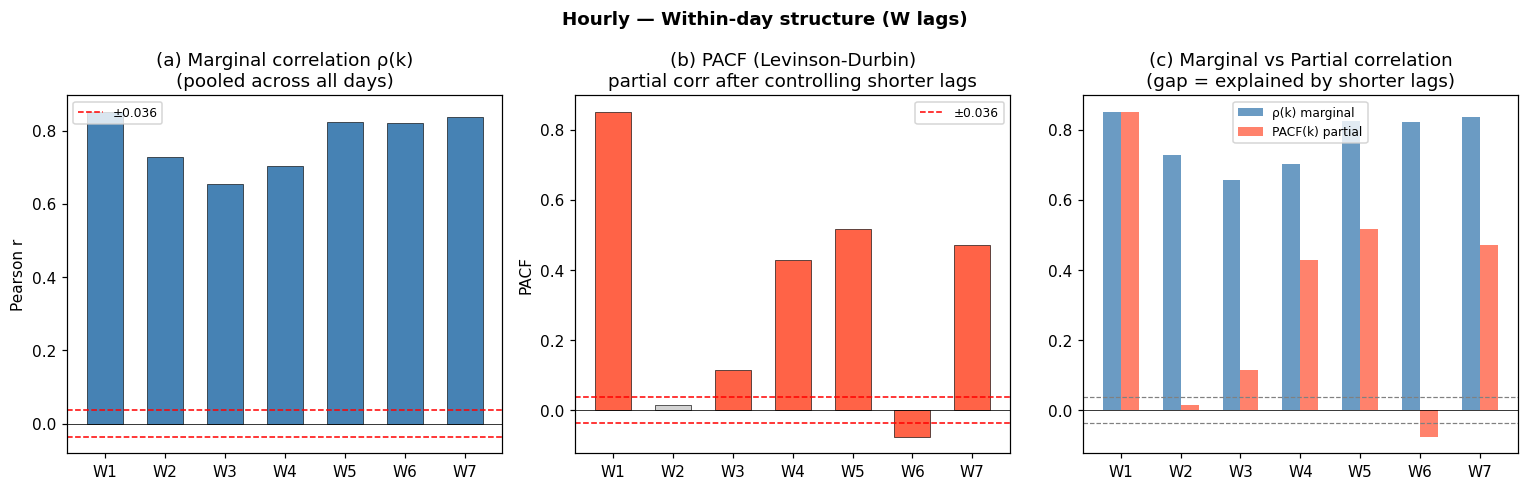


Note: W2 rho=0.73 ≈ 0.85² → fully explained by W1 (classic AR chain)
      W7 PACF=0.47 significant: strong slot0↔slot7 correlation within same day


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig.suptitle('Hourly — Within-day structure (W lags)', fontsize=12, fontweight='bold')

lags = np.arange(1, SLOTS)
xlabels = [f'W{k}' for k in lags]

# (a) Marginal rho
ax = axes[0]
bars = ax.bar(lags, rho_w, width=0.6, color=[
    'steelblue' if abs(rho_w[k-1]) > conf_per_lag[k-1] else 'lightgray'
    for k in lags], edgecolor='black', linewidth=0.4)
ax.axhline( conf_w, ls='--', color='red', lw=1.0, label=f'±{conf_w:.3f}')
ax.axhline(-conf_w, ls='--', color='red', lw=1.0)
ax.axhline(0, color='black', lw=0.5)
ax.set_xticks(lags); ax.set_xticklabels(xlabels)
ax.set_ylabel('Pearson r'); ax.set_title('(a) Marginal correlation ρ(k)\n(pooled across all days)')
ax.legend(fontsize=8)

# (b) PACF (Levinson-Durbin)
ax = axes[1]
colors_pacf = ['tomato' if abs(pacf_w[k]) > conf_per_lag[k-1] else 'lightgray' for k in lags]
ax.bar(lags, pacf_w[1:], width=0.6, color=colors_pacf, edgecolor='black', linewidth=0.4)
ax.axhline( conf_w, ls='--', color='red', lw=1.0, label=f'±{conf_w:.3f}')
ax.axhline(-conf_w, ls='--', color='red', lw=1.0)
ax.axhline(0, color='black', lw=0.5)
ax.set_xticks(lags); ax.set_xticklabels(xlabels)
ax.set_ylabel('PACF')
ax.set_title('(b) PACF (Levinson-Durbin)\npartial corr after controlling shorter lags')
ax.legend(fontsize=8)

# (c) rho vs PACF comparison
ax = axes[2]
w = 0.3
ax.bar(lags - w/2, rho_w,      width=w, label='ρ(k) marginal',  color='steelblue', alpha=0.8)
ax.bar(lags + w/2, pacf_w[1:], width=w, label='PACF(k) partial', color='tomato',    alpha=0.8)
ax.axhline(conf_w,  ls='--', color='gray', lw=0.8)
ax.axhline(-conf_w, ls='--', color='gray', lw=0.8)
ax.axhline(0, color='black', lw=0.5)
ax.set_xticks(lags); ax.set_xticklabels(xlabels)
ax.set_title('(c) Marginal vs Partial correlation\n(gap = explained by shorter lags)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print('\nNote: W2 rho=0.73 ≈ 0.85² → fully explained by W1 (classic AR chain)')
print('      W7 PACF=0.47 significant: strong slot0↔slot7 correlation within same day')

## 2. Hourly — Cross-day PACF (D lags)

In [6]:
max_cross = min(20, n_days - 5)

cross_pacf, cross_n = [], []
for h in range(SLOTS):
    col  = Y[:, h]
    pc, n = safe_pacf(col, max_cross)
    cross_pacf.append(pc)
    cross_n.append(n)

avg_pacf_c = np.array([
    np.nanmean([cross_pacf[h][li] for h in range(SLOTS)
                if cross_pacf[h] is not None and li < len(cross_pacf[h])])
    for li in range(max_cross + 1)])

conf_c = CONF_MULT / np.sqrt(np.nanmean(cross_n))

print(f'conf_c = ±{conf_c:.4f}  (avg n per slot ≈ {int(np.nanmean(cross_n))})')
print(f'{"Lag":<6} {"avg PACF":<12} {"sig"}')
print('-'*28)
for li in range(1, max_cross+1):
    s = '**' if abs(avg_pacf_c[li]) > conf_c else 'ns'
    print(f'D{li:<5} {avg_pacf_c[li]:+.4f}       {s}')

conf_c = ±0.0727  (avg n per slot ≈ 726)
Lag    avg PACF     sig
----------------------------
D1     +0.5650       **
D2     +0.0332       ns
D3     +0.0143       ns
D4     +0.0025       ns
D5     -0.0148       ns
D6     -0.0377       ns
D7     -0.0359       ns
D8     -0.0620       ns
D9     +0.0058       ns
D10    -0.0122       ns
D11    -0.0401       ns
D12    -0.0148       ns
D13    +0.0152       ns
D14    -0.0422       ns
D15    -0.0480       ns
D16    -0.0072       ns
D17    -0.0450       ns
D18    -0.0366       ns
D19    -0.0377       ns
D20    +0.0200       ns


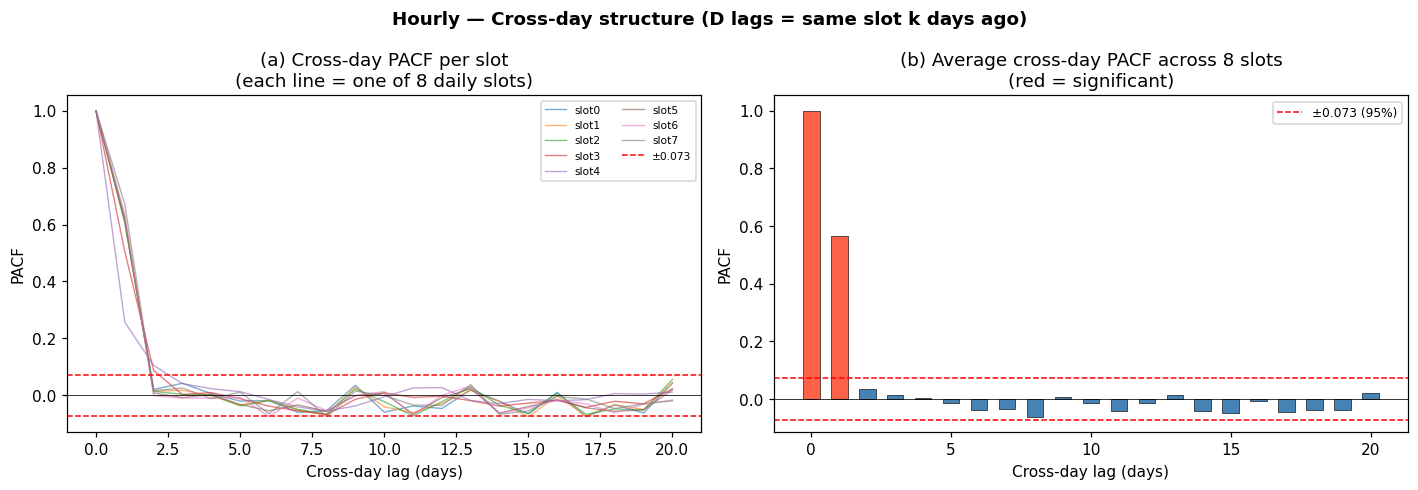


D1 significant (0.57): yesterday same-slot predicts today.
D2-D20 not significant: no weekly/biweekly pattern in cross-day same-slot.

Note: D1 was ΔAIC>3982 in AIC because AIC conditioned on W1-W6.
      Conditional on within-day info → D1 useless.
      Without within-day info → D1 very useful (0.57).


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('Hourly — Cross-day structure (D lags = same slot k days ago)', 
             fontsize=12, fontweight='bold')

# Per slot
ax = axes[0]
for h in range(SLOTS):
    if cross_pacf[h] is not None:
        ax.plot(range(len(cross_pacf[h])), cross_pacf[h],
                alpha=0.6, lw=0.9, label=f'slot{h}')
ax.axhline( conf_c, ls='--', color='red', lw=1.0, label=f'±{conf_c:.3f}')
ax.axhline(-conf_c, ls='--', color='red', lw=1.0)
ax.axhline(0, color='black', lw=0.5)
ax.set_xlabel('Cross-day lag (days)'); ax.set_ylabel('PACF')
ax.set_title('(a) Cross-day PACF per slot\n(each line = one of 8 daily slots)')
ax.legend(fontsize=7, ncol=2)

# Average
ax = axes[1]
colors_c = ['tomato' if abs(avg_pacf_c[li]) > conf_c else 'steelblue'
            for li in range(len(avg_pacf_c))]
ax.bar(range(len(avg_pacf_c)), avg_pacf_c, width=0.6,
       color=colors_c, edgecolor='black', linewidth=0.4)
ax.axhline( conf_c, ls='--', color='red', lw=1.0, label=f'±{conf_c:.3f} (95%)')
ax.axhline(-conf_c, ls='--', color='red', lw=1.0)
ax.axhline(0, color='black', lw=0.5)
ax.set_xlabel('Cross-day lag (days)'); ax.set_ylabel('PACF')
ax.set_title('(b) Average cross-day PACF across 8 slots\n(red = significant)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print('\nD1 significant (0.57): yesterday same-slot predicts today.')
print('D2-D20 not significant: no weekly/biweekly pattern in cross-day same-slot.')
print('\nNote: D1 was ΔAIC>3982 in AIC because AIC conditioned on W1-W6.')
print('      Conditional on within-day info → D1 useless.')
print('      Without within-day info → D1 very useful (0.57).')

## 3. Hourly — Cross-slot Cross-day Correlation (17–31h gaps)

**설명**: 전날 slot h' → 오늘 slot h 의 실제 시간 간격은 `gap = 24 + h − h'` 시간  
(h, h' ∈ {0,…,7}, gap 범위 = 17h ~ 31h)  
- gap=17h: 오늘 slot0 ← 어제 slot7  (가장 짧음)  
- gap=31h: 오늘 slot7 ← 어제 slot0  (가장 김)  

목표: 어제 각 slot과 오늘 각 slot 간의 피어슨 상관 8×8 행렬 확인

In [ ]:
# 8×8 correlation matrix: corr(Y[d, h], Y[d-1, h'])
# Row h = today's slot, Col h' = yesterday's slot
# gap(h, h') = 24 + h - h'  (hours)
corr_mat = np.full((SLOTS, SLOTS), np.nan)
n_mat    = np.zeros((SLOTS, SLOTS), dtype=int)
gap_mat  = np.full((SLOTS, SLOTS), np.nan)

for h in range(SLOTS):
    for hp in range(SLOTS):
        xs, ys = [], []
        for d in range(1, n_days):
            if np.isfinite(Y[d, h]) and np.isfinite(Y[d-1, hp]):
                xs.append(Y[d-1, hp])
                ys.append(Y[d,   h])
        if len(xs) > 10:
            corr_mat[h, hp] = np.corrcoef(xs, ys)[0, 1]
            n_mat[h, hp]    = len(xs)
        gap_mat[h, hp] = 24 + h - hp   # actual hour gap

conf_cs = CONF_MULT / np.sqrt(np.nanmin(n_mat[n_mat > 0]))   # conservative

print(f'Cross-slot cross-day correlation matrix  (row=today h, col=yesterday h\')')
print(f'conf = ±{conf_cs:.4f}  (n_min={np.nanmin(n_mat[n_mat>0])})\n')
header = '      ' + ''.join(f"y_h'{hp:<5}" for hp in range(SLOTS))
print(header)
print('-' * len(header))
for h in range(SLOTS):
    row = f"h={h}   "
    for hp in range(SLOTS):
        v = corr_mat[h, hp]
        sig = '*' if (np.isfinite(v) and abs(v) > conf_cs) else ' '
        row += f"{v:+.3f}{sig} "
    print(row)
print(f'\ngap_mat (hours):')
print(gap_mat.astype(int))

## 3. Daily — ACF & PACF

In [8]:
dv       = daily_z[np.isfinite(daily_z)]
max_dl   = min(30, len(dv)//3 - 1)
pc_d, nd = safe_pacf(daily_z, max_dl)
ac_d     = safe_acf(daily_z, max_dl)
conf_d   = CONF_MULT / np.sqrt(nd)

print(f'n={nd}, conf=±{conf_d:.4f}')
print(f'{"Lag":<6} {"ACF":<10} {"PACF":<10} {"ACF sig":<10} {"PACF sig"}')
print('-'*50)
for lag in range(1, max_dl+1):
    sa = '**' if ac_d is not None and abs(ac_d[lag]) > conf_d else 'ns'
    sp = '**' if pc_d is not None and lag < len(pc_d) and abs(pc_d[lag]) > conf_d else 'ns'
    ac_val = ac_d[lag] if ac_d is not None else np.nan
    pc_val = pc_d[lag] if pc_d is not None and lag < len(pc_d) else np.nan
    flag = ' ← AIC top' if lag in [1, 7, 8, 28] else ''
    print(f'L{lag:<5} {ac_val:+.4f}    {pc_val:+.4f}    {sa:<10} {sp}{flag}')

n=726, conf=±0.0727
Lag    ACF        PACF       ACF sig    PACF sig
--------------------------------------------------
L1     +0.6109    +0.6109    **         ** ← AIC top
L2     +0.3832    +0.0160    **         ns
L3     +0.2404    +0.0004    **         ns
L4     +0.1519    +0.0018    **         ns
L5     +0.0842    -0.0188    **         ns
L6     +0.0148    -0.0505    ns         ns
L7     -0.0426    -0.0475    ns         ns ← AIC top
L8     -0.0997    -0.0677    **         ns ← AIC top
L9     -0.1035    +0.0038    **         ns
L10    -0.0932    -0.0031    **         ns
L11    -0.0997    -0.0367    **         ns
L12    -0.1000    -0.0197    **         ns
L13    -0.0836    +0.0014    **         ns
L14    -0.0940    -0.0519    **         ns
L15    -0.1054    -0.0423    **         ns
L16    -0.1000    -0.0177    **         ns
L17    -0.1101    -0.0490    **         ns
L18    -0.1167    -0.0372    **         ns
L19    -0.1229    -0.0416    **         ns
L20    -0.0914    +0.0161    **  

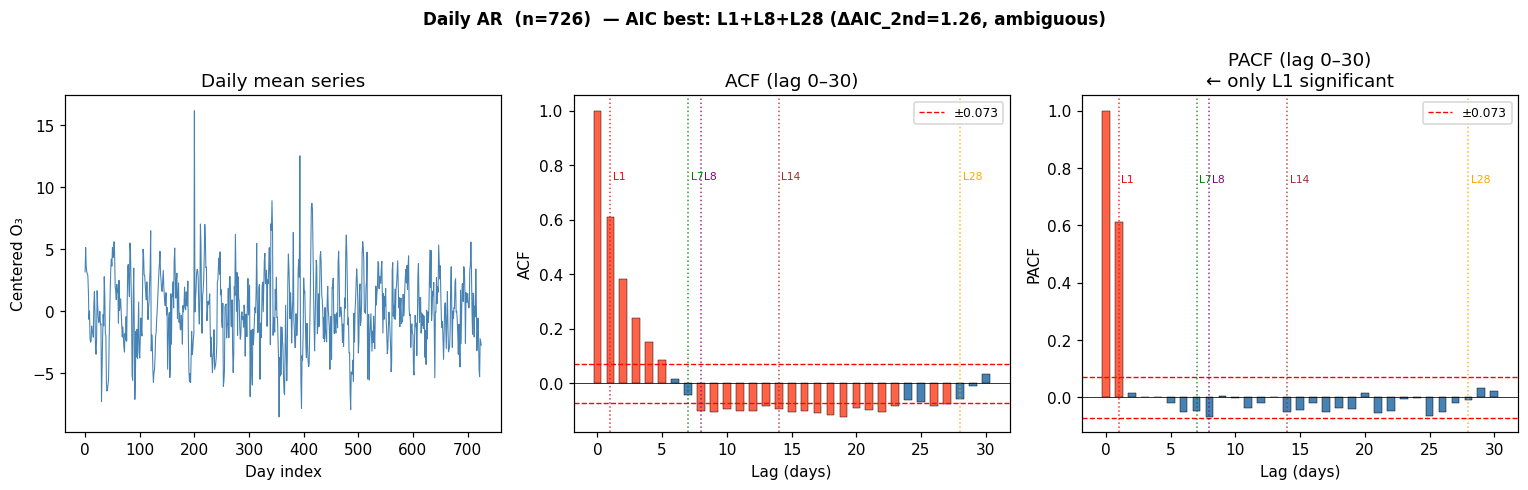


PACF result: Only L1 significant (0.61).
L7, L8, L28: NOT significant in PACF → AIC selection (ΔAIC=1.26) is noise.
Practical model: AR(1) is adequate for daily scale.


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig.suptitle(f'Daily AR  (n={nd})  — AIC best: L1+L8+L28 (ΔAIC_2nd=1.26, ambiguous)',
             fontsize=11, fontweight='bold')

axes[0].plot(daily_z, lw=0.7, color='steelblue')
axes[0].set_xlabel('Day index'); axes[0].set_ylabel('Centered O₃')
axes[0].set_title('Daily mean series')

highlight = {1:'red', 7:'green', 8:'purple', 14:'brown', 28:'orange'}

for ax, vals, ylabel, title in [
    (axes[1], ac_d, 'ACF', f'ACF (lag 0–{max_dl})'),
    (axes[2], pc_d, 'PACF', f'PACF (lag 0–{max_dl})\n← only L1 significant')]:
    if vals is None: continue
    colors = ['tomato' if abs(vals[i]) > conf_d else 'steelblue'
              for i in range(len(vals))]
    ax.bar(range(len(vals)), vals, width=0.6, color=colors,
           edgecolor='black', linewidth=0.3)
    ax.axhline( conf_d, ls='--', color='red', lw=0.9, label=f'±{conf_d:.3f}')
    ax.axhline(-conf_d, ls='--', color='red', lw=0.9)
    ax.axhline(0, color='black', lw=0.5)
    for lag, col in highlight.items():
        if lag < len(vals):
            ax.axvline(lag, color=col, lw=1.0, ls=':', alpha=0.8)
            ax.text(lag + 0.2, max(vals)*0.75, f'L{lag}', color=col, fontsize=7)
    ax.set_xlabel('Lag (days)'); ax.set_ylabel(ylabel)
    ax.set_title(title); ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print('\nPACF result: Only L1 significant (0.61).')
print('L7, L8, L28: NOT significant in PACF → AIC selection (ΔAIC=1.26) is noise.')
print('Practical model: AR(1) is adequate for daily scale.')

## 4. Monthly — ACF & PACF

In [10]:
mv     = monthly_z[np.isfinite(monthly_z)]
max_ml = min(len(mv)-2, len(mv)//3 - 1)
pc_m, nm = safe_pacf(monthly_z, max_ml)
ac_m     = safe_acf(monthly_z, max_ml)
conf_m   = CONF_MULT / np.sqrt(nm)

print(f'n={nm}, conf=±{conf_m:.4f}  (wide band — low power with n=24)')
print(f'{"Lag":<6} {"ACF":<10} {"PACF":<10} {"PACF sig"}')
print('-'*38)
for lag in range(1, len(pc_m) if pc_m is not None else 1):
    sp = '**' if abs(pc_m[lag]) > conf_m else 'ns'
    ac_val = ac_m[lag] if ac_m is not None and lag < len(ac_m) else np.nan
    flag = '  ← same month prev year' if lag==6 else ''
    print(f'L{lag:<5} {ac_val:+.4f}    {pc_m[lag]:+.4f}    {sp}{flag}')

n=24, conf=±0.4001  (wide band — low power with n=24)
Lag    ACF        PACF       PACF sig
--------------------------------------
L1     +0.0033    +0.0033    ns
L2     -0.0515    -0.0515    ns
L3     -0.3691    -0.3697    ns
L4     +0.2019    +0.2262    ns
L5     -0.0572    -0.1283    ns
L6     +0.0383    -0.0788    ns  ← same month prev year
L7     -0.3548    -0.2540    ns


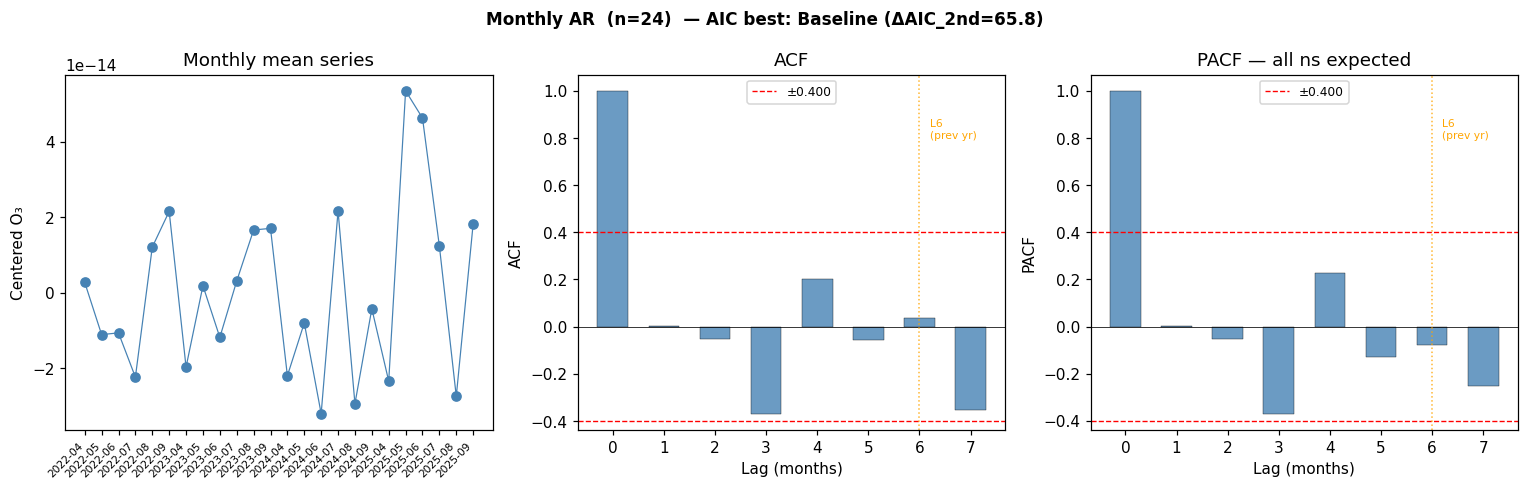

All PACF ns → Baseline confirmed. No inter-annual autocorrelation.


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig.suptitle(f'Monthly AR  (n={nm})  — AIC best: Baseline (ΔAIC_2nd=65.8)',
             fontsize=11, fontweight='bold')

mo_labels = [f"{int(r['year'])}-{int(r['month']):02d}"
             for _, r in (df.groupby(['year','month'])['spatial_mean_c']
                            .mean().reset_index().sort_values(['year','month'])).iterrows()]
axes[0].plot(monthly_z, 'o-', lw=0.8, color='steelblue')
axes[0].set_xticks(range(len(monthly_z)))
axes[0].set_xticklabels(mo_labels, rotation=45, ha='right', fontsize=7)
axes[0].set_ylabel('Centered O₃'); axes[0].set_title('Monthly mean series')

for ax, vals, ylabel, title in [
    (axes[1], ac_m, 'ACF', 'ACF'),
    (axes[2], pc_m, 'PACF', 'PACF — all ns expected')]:
    if vals is None: continue
    ax.bar(range(len(vals)), vals, width=0.6, color='steelblue',
           edgecolor='black', linewidth=0.3, alpha=0.8)
    ax.axhline( conf_m, ls='--', color='red', lw=0.9, label=f'±{conf_m:.3f}')
    ax.axhline(-conf_m, ls='--', color='red', lw=0.9)
    ax.axhline(0, color='black', lw=0.5)
    if len(vals) > 6:
        ax.axvline(6, color='orange', lw=1.0, ls=':', alpha=0.8)
        ax.text(6.2, max(vals)*0.8, 'L6\n(prev yr)', color='orange', fontsize=7)
    ax.set_xlabel('Lag (months)'); ax.set_ylabel(ylabel)
    ax.set_title(title); ax.legend(fontsize=8)

plt.tight_layout()
plt.show()
print('All PACF ns → Baseline confirmed. No inter-annual autocorrelation.')

## 5. Summary

In [12]:
print('=' * 65)
print('  SEASONAL AR SUMMARY')
print('=' * 65)

print('''
HOURLY — Within-day (W lags)
  Significant PACF : W1, W3, W4, W5, W7  (W2, W6 borderline/ns)
  W2 not needed    : rho(2)=0.73 ≈ 0.85² → fully explained by W1
  W7 is real       : 0.47 partial corr (slot0↔slot7 within same day)
  AIC said W7 useless — but that's because AIC compared models on
  different sample sizes (NaN masking reduces n: 5808→726)

HOURLY — Cross-day (D lags)
  D1 significant (0.57) when considered alone (same-slot PACF)
  D2–D20 not significant
  D1 AIC-useless only when W1–W6 already in model
  → Cross-day effect is real but MEDIATED by within-day structure

DAILY
  Only L1 significant in PACF (0.61)
  L7, L8, L28 NOT significant (PACF ≈ 0)
  AIC selected L1+L8+L28 with ΔAIC_2nd=1.26 → noise, not structure
  → AR(1) is adequate for daily scale

MONTHLY
  All PACF ns → Baseline (no autocorrelation) confirmed
  Caveat: n=24, wide bands (±0.40)
''')

print('=' * 65)
print('  Implications for spatiotemporal model')
print('=' * 65)
print('''
  Within-day correlation : strong, AR-like over 6–7h window
  Day-to-day correlation : AR(1) only — exponential decay
  Weekly / monthly cycle : NOT present in partial autocorrelation
  Inter-annual           : no autocorrelation
  → Model with exponential temporal decay (Matérn/Cauchy) is appropriate
''')

  SEASONAL AR SUMMARY

HOURLY — Within-day (W lags)
  Significant PACF : W1, W3, W4, W5, W7  (W2, W6 borderline/ns)
  W2 not needed    : rho(2)=0.73 ≈ 0.85² → fully explained by W1
  W7 is real       : 0.47 partial corr (slot0↔slot7 within same day)
  AIC said W7 useless — but that's because AIC compared models on
  different sample sizes (NaN masking reduces n: 5808→726)

HOURLY — Cross-day (D lags)
  D1 significant (0.57) when considered alone (same-slot PACF)
  D2–D20 not significant
  D1 AIC-useless only when W1–W6 already in model
  → Cross-day effect is real but MEDIATED by within-day structure

DAILY
  Only L1 significant in PACF (0.61)
  L7, L8, L28 NOT significant (PACF ≈ 0)
  AIC selected L1+L8+L28 with ΔAIC_2nd=1.26 → noise, not structure
  → AR(1) is adequate for daily scale

MONTHLY
  All PACF ns → Baseline (no autocorrelation) confirmed
  Caveat: n=24, wide bands (±0.40)

  Implications for spatiotemporal model

  Within-day correlation : strong, AR-like over 6–7h window
